# Feeding Rate Equation

Dynamic Energy Budget V1-morph expression from `feeding_rate_in_DEB.md`:
$$
f_{\text{feed}}(X) = \frac{\{\dot{p}_{Am}\}\,\{\dot{F}_m\}}{\{\dot{p}_{Am}\} + \kappa_{\text{bite}}\,\kappa_X\,\mu_X\,\{\dot{F}_m\}\,X}.
$$
Units check:
$$
[f_{\text{feed}}] = \frac{\mathrm{J\,cm^{-3}\,d^{-1}}\times\mathrm{cm^{3}\,cm^{-3}\,d^{-1}}}{\mathrm{J\,cm^{-3}\,d^{-1}}} = \mathrm{d^{-1}}.
$$

**Parameters used below**

| Symbol | Name | Value | Units |
| --- | --- | ---: | --- |
| $\{\dot{p}_{Am}\}$ | volume-specific max assimilation rate | 229.251 | J·cm<sup>-3</sup>·d<sup>-1</sup> |
| $\{\dot{F}_m\}$ | volume-specific max searching/clearance rate | 6.5 | cm<sup>3</sup>·cm<sup>-3</sup>·d<sup>-1</sup> |
| $\kappa_{\text{bite}}$ | bite-volume fraction of body volume | 0.001 | - |
| $\kappa_X$ | conversion efficiency | rovers: 0.5; sitters: 0.15 | - |
| $\mu_X$ | food energy density | 525,000 | J·C-mol<sup>-1</sup> |
| $X$ | environmental food concentration (independent variable) | — | C-mol·cm<sup>-3</sup> |

The function decreases with increasing $X$ because the DEB flux chain caps assimilation at $\{\dot{p}_{Am}\}$; higher $X$ requires fewer feeding motions to meet that cap.

In [5]:
import numpy as np


def f_feed(x, p_am, f_m, kappa_x, mu_x, kappa_bite):
    """DEB V1-morph feeding rate (motions per day) as in feeding_rate_in_DEB.md."""
    x = np.asarray(x, dtype=float)
    numerator = p_am * f_m
    denominator = p_am + kappa_bite * kappa_x * mu_x * f_m * x
    return numerator / denominator


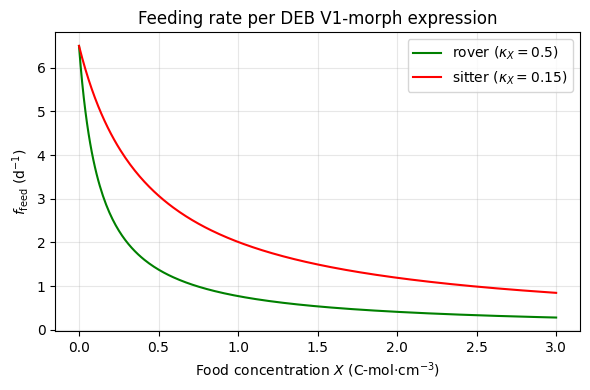

In [6]:
import matplotlib.pyplot as plt

# X range (food concentration)
X = np.linspace(0, 3, 300)

# Fixed parameters from DEB model and assumptions
p_am = 229.251   # volume-specific max assimilation
f_m = 6.5        # volume-specific max searching/clearance rate
mu_x = 525000.0  # food energy density (match DEB energy units)
kappa_bite = 0.001

# Conversion efficiencies
kappa_x_rover = 0.5
kappa_x_sitter = 0.15

f_rover = f_feed(X, p_am, f_m, kappa_x_rover, mu_x, kappa_bite)
f_sitter = f_feed(X, p_am, f_m, kappa_x_sitter, mu_x, kappa_bite)

plt.figure(figsize=(6, 4))
plt.plot(X, f_rover, color="green", label=rf"rover ($\kappa_X={kappa_x_rover}$)")
plt.plot(X, f_sitter, color="red", label=rf"sitter ($\kappa_X={kappa_x_sitter}$)")
plt.xlabel(r"Food concentration $X$ (C-mol·cm$^{-3}$)")
plt.ylabel(r"$f_{\mathrm{feed}}$ (d$^{-1}$)")
plt.title("Feeding rate per DEB V1-morph expression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
